In [ ]:
!pip install tensorflow


In [3]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Add, Multiply, Softmax, Reshape

In [4]:
ruta = "./DataframeTrabajoFinal.xlsx"


df = pd.read_excel(ruta)
df.head()

,FileName,Rhythm,SDNN,RMSSD,dct_mean,dct_std,frecuencia_pico,energia_total,mfcc_energy,mfcc_entropy,prominencia_QRS,num_peaks_no_QRS
0,MUSE_20180712_160452_75000.csv,AFIB,NaN,NaN,92.363963,122.408366,3.3,2.094985e+11,8742.477472,-29976.562729,1031.163,19
1,MUSE_20180118_131905_87000.csv,AFIB,47.066012,64.286291,46.453627,94.612546,2.6,2.286271e+10,11401.140754,-43937.755827,278.035,1
2,MUSE_20180114_071444_05000.csv,AFIB,107.932618,182.181594,60.068963,70.975279,4.4,1.633629e+11,11189.783740,-41579.363721,749.454,6
3,MUSE_20180114_132956_24000.csv,AFIB,122.117670,155.869768,64.398593,90.512614,1.5,3.567487e+11,11041.465633,-41342.370863,1416.650,7
4,MUSE_20180118_124852_18000.csv,AFIB,72.790109,87.143560,68.018461,87.664136,6.8,4.895104e+11,12733.285470,-51120.982936,1583.360,5


In [5]:
df['Rhythm'].unique()

array(['AFIB', 'SB', 'SR', 'SVT'], dtype=object)

In [6]:
# Ver primeras filas
print("Primeras filas:")
display(df.head())

# Dimensiones del dataset
print(f"\nDimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")

# Tipos de datos
print("\nTipos de datos:")
display(df.dtypes)

# Columnas disponibles
print("\nNombres de columnas:")
print(df.columns.tolist())

# Nulos por columna
print("\nValores nulos por columna:")
display(df.isnull().sum())

# Estadísticas básicas
print("\nEstadísticas básicas:")
display(df.describe())

# Distribución del GRD
print("\nDistribución de la variable objetivo (GRD -Código):")
display(df['Rhythm'].value_counts())



Primeras filas:


,FileName,Rhythm,SDNN,RMSSD,dct_mean,dct_std,frecuencia_pico,energia_total,mfcc_energy,mfcc_entropy,prominencia_QRS,num_peaks_no_QRS
0,MUSE_20180712_160452_75000.csv,AFIB,NaN,NaN,92.363963,122.408366,3.3,2.094985e+11,8742.477472,-29976.562729,1031.163,19
1,MUSE_20180118_131905_87000.csv,AFIB,47.066012,64.286291,46.453627,94.612546,2.6,2.286271e+10,11401.140754,-43937.755827,278.035,1
2,MUSE_20180114_071444_05000.csv,AFIB,107.932618,182.181594,60.068963,70.975279,4.4,1.633629e+11,11189.783740,-41579.363721,749.454,6
3,MUSE_20180114_132956_24000.csv,AFIB,122.117670,155.869768,64.398593,90.512614,1.5,3.567487e+11,11041.465633,-41342.370863,1416.650,7
4,MUSE_20180118_124852_18000.csv,AFIB,72.790109,87.143560,68.018461,87.664136,6.8,4.895104e+11,12733.285470,-51120.982936,1583.360,5



Dimensiones del dataset: 5596 filas, 12 columnas

Tipos de datos:


FileName             object
Rhythm               object
SDNN                float64
RMSSD               float64
dct_mean            float64
dct_std             float64
frecuencia_pico     float64
energia_total       float64
mfcc_energy         float64
mfcc_entropy        float64
prominencia_QRS     float64
num_peaks_no_QRS      int64
dtype: object


Nombres de columnas:
['FileName', 'Rhythm', 'SDNN', 'RMSSD', 'dct_mean', 'dct_std', 'frecuencia_pico', 'energia_total', 'mfcc_energy', 'mfcc_entropy', 'prominencia_QRS', 'num_peaks_no_QRS']

Valores nulos por columna:


FileName               0
Rhythm                 0
SDNN                3759
RMSSD               3759
dct_mean              43
dct_std               43
frecuencia_pico        0
energia_total          0
mfcc_energy           33
mfcc_entropy          33
prominencia_QRS        0
num_peaks_no_QRS       0
dtype: int64


Estadísticas básicas:


,SDNN,RMSSD,dct_mean,dct_std,frecuencia_pico,energia_total,mfcc_energy,mfcc_entropy,prominencia_QRS,num_peaks_no_QRS
count,1837.000000,1837.000000,5553.000000,5553.000000,5596.000000,5.596000e+03,5563.000000,5563.000000,5596.000000,5596.000000
mean,66.714040,90.116788,81.919257,101.240474,3.321122,2.639087e+11,10609.649697,-39446.582516,1011.785033,11.356505
std,71.729253,106.374829,21.525564,30.689523,2.291750,3.263149e+11,1592.199334,8402.577037,407.889436,5.491659
min,0.650880,0.925820,25.533420,26.244238,0.000000,0.000000e+00,7141.487239,-99764.316914,0.000000,0.000000
25%,6.235286,5.903994,67.726143,79.886073,1.700000,1.019154e+11,9529.095841,-42811.142895,740.847750,9.000000
50%,35.083882,37.489392,82.122554,98.737320,3.000000,1.754819e+11,10198.757607,-37324.364931,957.380000,12.000000
75%,115.850871,158.633132,97.809412,119.699613,4.200000,3.072220e+11,11257.298851,-33822.971258,1224.392750,15.000000
max,383.006606,630.609229,153.424004,314.368107,23.100000,6.075657e+12,20814.852634,-21637.328183,7475.790000,29.000000



Distribución de la variable objetivo (GRD -Código):


Rhythm
SB      2640
SR      1476
AFIB     992
SVT      488
Name: count, dtype: int64

C:\Users\CAROLINA\AppData\Local\Temp\ipykernel_36616\3674128302.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nulls_by_rhythm = df.groupby("Rhythm").apply(lambda g: g.isnull().mean() * 100)


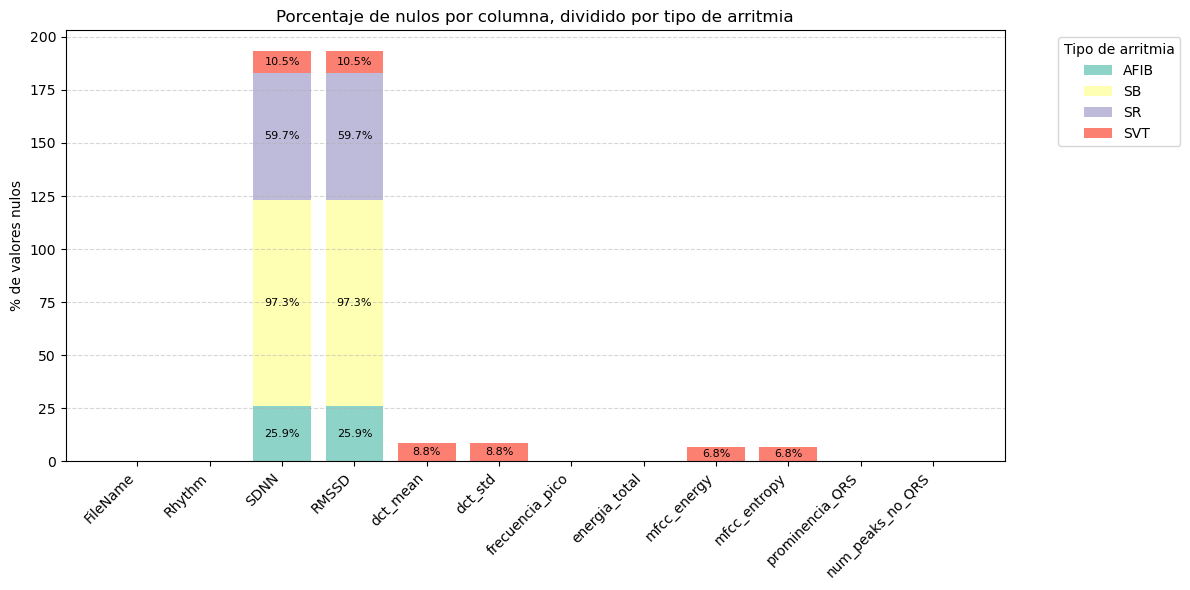

In [7]:

# Paso 1: Calcular % de nulos por grupo (Rhythm)
nulls_by_rhythm = df.groupby("Rhythm").apply(lambda g: g.isnull().mean() * 100)

# Paso 2: Transponer para que las columnas sean variables y las filas los nombres de columnas de df
nulls_by_rhythm = nulls_by_rhythm.T

# Paso 3: Crear gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.get_cmap('Set3').colors

# Para guardar la posición acumulada de cada parte de la barra
bottom = [0] * len(nulls_by_rhythm)

# Graficar manualmente cada segmento
for i, rhythm in enumerate(nulls_by_rhythm.columns):
    values = nulls_by_rhythm[rhythm]
    bars = ax.bar(nulls_by_rhythm.index, values, bottom=bottom, label=rhythm, color=colors[i % len(colors)])
    
    # Etiquetas dentro de la barra
    for bar, value, base in zip(bars, values, bottom):
        if value > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                base + value / 2,
                f"{value:.1f}%",
                ha='center', va='center',
                fontsize=8,
                color='black'
            )
    
    # Actualizar base para la siguiente capa
    bottom = [b + v for b, v in zip(bottom, values)]

# Estética
ax.set_ylabel('% de valores nulos')
ax.set_title('Porcentaje de nulos por columna, dividido por tipo de arritmia')
plt.xticks(rotation=45, ha='right')
ax.legend(title='Tipo de arritmia', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [8]:
rhythm_col =  "Rhythm"

# Filtrar SVT y reemplazar nulos con la media de cada columna
svt_mask = df[rhythm_col] == 'SVT'
numeric_cols = df.select_dtypes(include=['number']).columns.difference([rhythm_col])

df.loc[svt_mask, numeric_cols] = df.loc[svt_mask, numeric_cols].fillna(
    df.loc[svt_mask, numeric_cols].mean()
)

In [9]:
columnas_drop = ['SDNN', 'RMSSD','FileName']
df_procesar = df.drop(columns=columnas_drop).copy()

In [10]:
df_procesar

,Rhythm,dct_mean,dct_std,frecuencia_pico,energia_total,mfcc_energy,mfcc_entropy,prominencia_QRS,num_peaks_no_QRS
0,AFIB,92.363963,122.408366,3.3,2.094985e+11,8742.477472,-29976.562729,1031.163,19
1,AFIB,46.453627,94.612546,2.6,2.286271e+10,11401.140754,-43937.755827,278.035,1
2,AFIB,60.068963,70.975279,4.4,1.633629e+11,11189.783740,-41579.363721,749.454,6
3,AFIB,64.398593,90.512614,1.5,3.567487e+11,11041.465633,-41342.370863,1416.650,7
4,AFIB,68.018461,87.664136,6.8,4.895104e+11,12733.285470,-51120.982936,1583.360,5
...,...,...,...,...,...,...,...,...,...
5591,SVT,42.096208,62.046866,5.4,3.608043e+11,13335.746435,-52370.561231,881.430,0
5592,SVT,40.534300,54.208733,5.6,4.859333e+11,13595.406936,-53121.208395,1149.110,0
5593,SVT,42.619620,46.423275,5.2,8.150690e+11,15345.497009,-65654.525875,1718.700,1
5594,SVT,39.128622,66.596965,6.9,1.532650e+12,15224.691672,-61421.055236,1589.830,3


### Eliminacion del SDNN y RMSSD

Debido a que estas caracteristicas poseen una gran cantidad de nulos, se descarta para el analisis de la redes neuronales, aparte el SVT al tener tan pocos elementos, se pondra el valor medio.

In [11]:
# Separar características y etiquetas
X = df_procesar.drop('Rhythm', axis=1)
y = df_procesar['Rhythm']

# División 80% entrenamiento, 20% prueba (con estratificación para mantener proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (4476, 8)
Tamaño prueba: (1120, 8)


## Arquitectura base (MLP simple)

c:\Users\CAROLINA\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 MLP Base:
Precisión en entrenamiento: 0.8320
Precisión en prueba: 0.8339
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


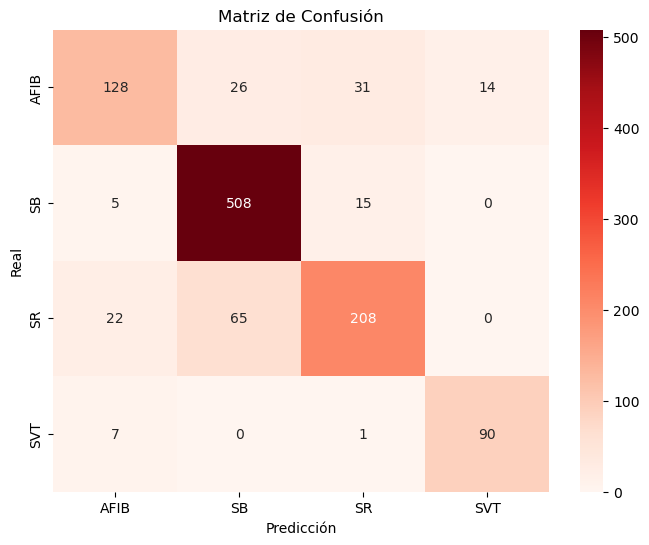


Reporte de clasificación:

              precision    recall  f1-score   support

        AFIB       0.79      0.64      0.71       199
          SB       0.85      0.96      0.90       528
          SR       0.82      0.71      0.76       295
         SVT       0.87      0.92      0.89        98

    accuracy                           0.83      1120
   macro avg       0.83      0.81      0.81      1120
weighted avg       0.83      0.83      0.83      1120



In [ ]:
# 1. Cargar y preparar datos

# X = características, y = etiqueta
X = df_procesar.drop('Rhythm', axis=1)
y = df_procesar['Rhythm']

# Codificar etiquetas (AFIB, SVT, etc.) en números
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Escalar características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 2. División entrenamiento / prueba

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


# 3. Definir modelo MLP

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(len(np.unique(y_encoded)), activation='softmax')  # tantas neuronas como clases
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


# 4. Entrenamiento

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)


# 5. Evaluación

train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"\n MLP Base:")
print(f"Precisión en entrenamiento: {train_acc:.4f}")
print(f"Precisión en prueba: {test_acc:.4f}")


# 6. Matriz de confusión

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
class_names = encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Reds')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()


# 7. Reporte de clasificación 

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

## MLP profunda (Deep MLP).

c:\Users\CAROLINA\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 MLP Profundo:
Precisión en entrenamiento: 0.8465
Precisión en prueba: 0.8286
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


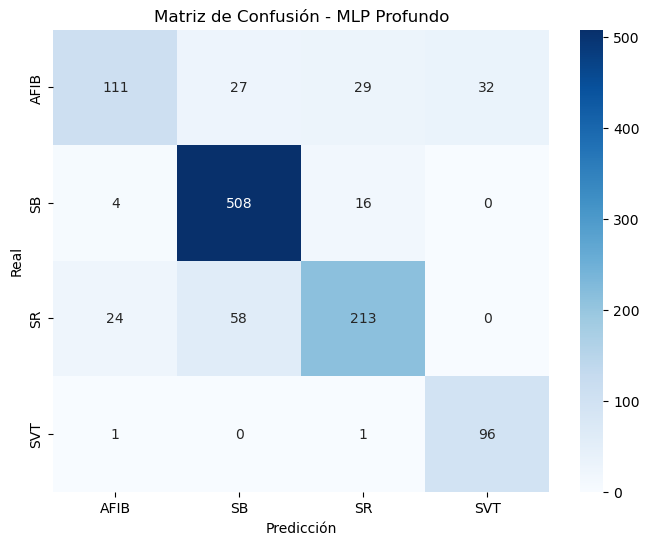


Reporte de clasificación - MLP Profundo:

              precision    recall  f1-score   support

        AFIB       0.79      0.56      0.65       199
          SB       0.86      0.96      0.91       528
          SR       0.82      0.72      0.77       295
         SVT       0.75      0.98      0.85        98

    accuracy                           0.83      1120
   macro avg       0.81      0.81      0.79      1120
weighted avg       0.83      0.83      0.82      1120



In [13]:

# 3. Modelo MLP profundo

deep_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dense(len(np.unique(y_encoded)), activation='softmax')  # capa de salida
])

deep_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# 4. Entrenamiento

history_deep = deep_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)


# 5. Evaluación

train_loss_d, train_acc_d = deep_model.evaluate(X_train, y_train, verbose=0)
test_loss_d, test_acc_d = deep_model.evaluate(X_test, y_test, verbose=0)

print(f"\n MLP Profundo:")
print(f"Precisión en entrenamiento: {train_acc_d:.4f}")
print(f"Precisión en prueba: {test_acc_d:.4f}")


# 6. Matriz de confusión

y_pred_d = deep_model.predict(X_test)
y_pred_classes_d = np.argmax(y_pred_d, axis=1)

cm_d = confusion_matrix(y_test, y_pred_classes_d)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_d, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - MLP Profundo')
plt.show()


# 7. Reporte de clasificación

print("\nReporte de clasificación - MLP Profundo:\n")
print(classification_report(y_test, y_pred_classes_d, target_names=class_names))

## MLP con conexiones residuales (tipo ResNet adaptada para datos tabulares).


 MLP con conexión residual:
Precisión en entrenamiento: 0.8362
Precisión en prueba: 0.8179
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


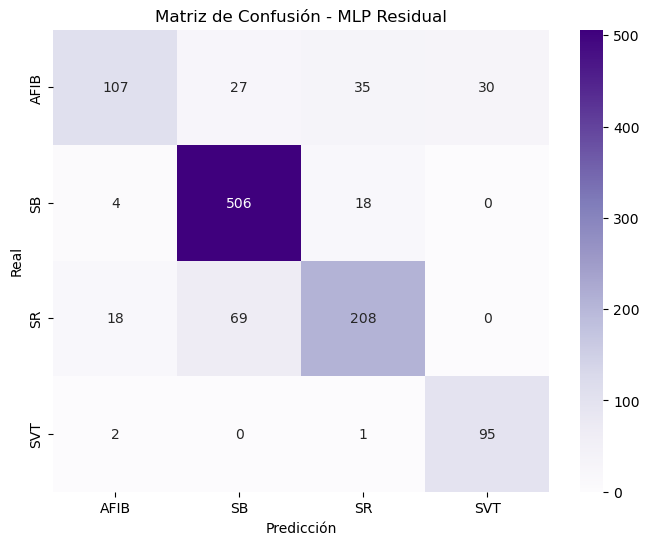


Reporte de clasificación - MLP Residual:

              precision    recall  f1-score   support

        AFIB       0.82      0.54      0.65       199
          SB       0.84      0.96      0.90       528
          SR       0.79      0.71      0.75       295
         SVT       0.76      0.97      0.85        98

    accuracy                           0.82      1120
   macro avg       0.80      0.79      0.79      1120
weighted avg       0.82      0.82      0.81      1120



In [14]:

# 1. Definición del modelo residual


# Capa de entrada
input_layer = Input(shape=(X_train.shape[1],))

# Primer bloque
x = Dense(64, activation='relu')(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Segundo bloque (residual)
res = Dense(64, activation='relu')(x)
res = BatchNormalization()(res)
res = Dropout(0.3)(res)

# Suma residual
x = Add()([x, res])

# Tercer bloque
x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)

# Capa de salida
output_layer = Dense(len(np.unique(y_encoded)), activation='softmax')(x)

# Modelo final
residual_model = Model(inputs=input_layer, outputs=output_layer)

residual_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])


# 2. Entrenamiento

history_res = residual_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)


# 3. Evaluación

train_loss_r, train_acc_r = residual_model.evaluate(X_train, y_train, verbose=0)
test_loss_r, test_acc_r = residual_model.evaluate(X_test, y_test, verbose=0)

print(f"\n MLP con conexión residual:")
print(f"Precisión en entrenamiento: {train_acc_r:.4f}")
print(f"Precisión en prueba: {test_acc_r:.4f}")


# 4. Matriz de confusión

y_pred_r = residual_model.predict(X_test)
y_pred_classes_r = np.argmax(y_pred_r, axis=1)

cm_r = confusion_matrix(y_test, y_pred_classes_r)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_r, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Purples')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - MLP Residual')
plt.show()


# 5. Reporte de clasificación

print("\nReporte de clasificación - MLP Residual:\n")
print(classification_report(y_test, y_pred_classes_r, target_names=class_names))

## Red con atención simple sobre features


 Red con atención simple:
Precisión en entrenamiento: 0.8112
Precisión en prueba: 0.8027
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


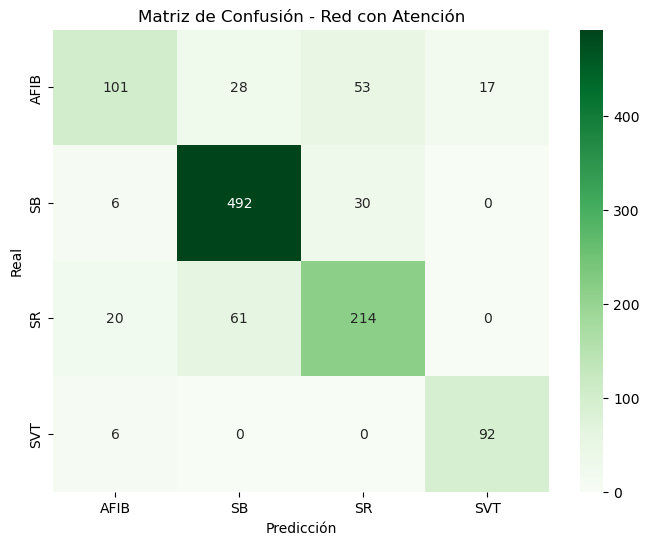


Reporte de clasificación - Red con Atención:

              precision    recall  f1-score   support

        AFIB       0.76      0.51      0.61       199
          SB       0.85      0.93      0.89       528
          SR       0.72      0.73      0.72       295
         SVT       0.84      0.94      0.89        98

    accuracy                           0.80      1120
   macro avg       0.79      0.78      0.78      1120
weighted avg       0.80      0.80      0.79      1120



In [15]:

# 1. Red con atención sobre features

# Capa de entrada
input_layer = Input(shape=(X_train.shape[1],))

# Generamos un vector de pesos de atención
attention_probs = Dense(X_train.shape[1], activation='softmax', name='attention_vec')(input_layer)

# Aplicamos la atención: se ponderan las entradas
attention_mul = Multiply()([input_layer, attention_probs])

# Capa oculta tradicional después de atención
x = Dense(64, activation='relu')(attention_mul)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)

# Capa de salida
output_layer = Dense(len(np.unique(y_encoded)), activation='softmax')(x)

# Definir modelo
attention_model = Model(inputs=input_layer, outputs=output_layer)

attention_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])


# 2. Entrenamiento

history_att = attention_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)


# 3. Evaluación

train_loss_a, train_acc_a = attention_model.evaluate(X_train, y_train, verbose=0)
test_loss_a, test_acc_a = attention_model.evaluate(X_test, y_test, verbose=0)

print(f"\n Red con atención simple:")
print(f"Precisión en entrenamiento: {train_acc_a:.4f}")
print(f"Precisión en prueba: {test_acc_a:.4f}")

# 4. Matriz de confusión

y_pred_a = attention_model.predict(X_test)
y_pred_classes_a = np.argmax(y_pred_a, axis=1)

cm_a = confusion_matrix(y_test, y_pred_classes_a)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_a, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Red con Atención')
plt.show()

# 5. Reporte de clasificación

print("\nReporte de clasificación - Red con Atención:\n")
print(classification_report(y_test, y_pred_classes_a, target_names=class_names))

In [16]:
# Filtrar el DataFrame original para conservar solo SB y SR
df_binario = df_procesar[df['Rhythm'].isin(['SB', 'SR'])].copy()

# Reiniciar el índice
df_binario.reset_index(drop=True, inplace=True)

# Verificar distribución de clases
print("Distribución de clases en la nueva base de datos:")
print(df_binario['Rhythm'].value_counts())

Distribución de clases en la nueva base de datos:
Rhythm
SB    2640
SR    1476
Name: count, dtype: int64


In [17]:
# Separar características y etiquetas
X = df_binario.drop('Rhythm', axis=1)
y = df_binario['Rhythm']

# División 80% entrenamiento, 20% prueba (con estratificación para mantener proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (3292, 8)
Tamaño prueba: (824, 8)


## Arquitectura base (MLP simple)

c:\Users\CAROLINA\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 MLP Base:
Precisión en entrenamiento: 0.9089
Precisión en prueba: 0.8847
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


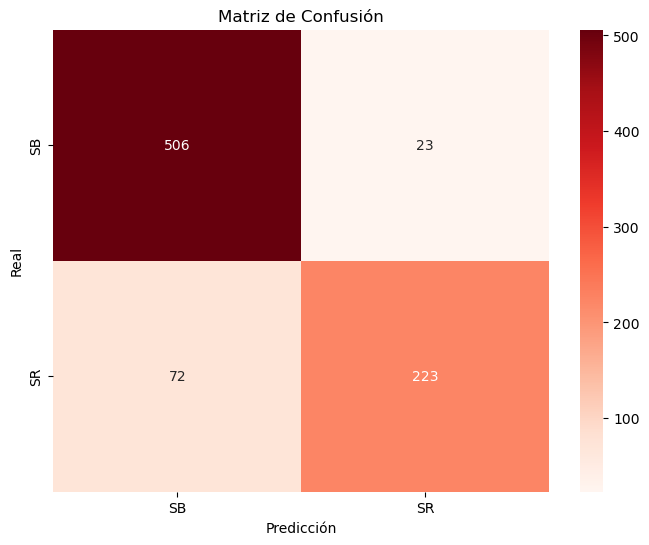


Reporte de clasificación:

              precision    recall  f1-score   support

          SB       0.88      0.96      0.91       529
          SR       0.91      0.76      0.82       295

    accuracy                           0.88       824
   macro avg       0.89      0.86      0.87       824
weighted avg       0.89      0.88      0.88       824



In [18]:

# 1. Cargar y preparar datos


# Supón que tu DataFrame ya está cargado como df
# X = características, y = etiqueta

# Codificar etiquetas (AFIB, SVT, etc.) en números
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Escalar características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 2. División entrenamiento / prueba

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


# 3. Definir modelo MLP

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(len(np.unique(y_encoded)), activation='softmax')  # tantas neuronas como clases
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


# 4. Entrenamiento

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)


# 5. Evaluación

train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"\n MLP Base:")
print(f"Precisión en entrenamiento: {train_acc:.4f}")
print(f"Precisión en prueba: {test_acc:.4f}")

# 6. Matriz de confusión

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
class_names = encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Reds')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()


# 7. Reporte de clasificación 
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

c:\Users\CAROLINA\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 MLP Profundo:
Precisión en entrenamiento: 0.9152
Precisión en prueba: 0.9005
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


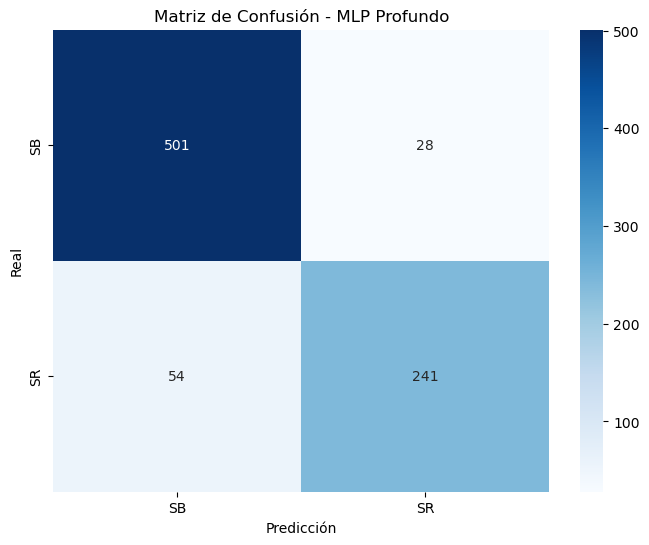


Reporte de clasificación - MLP Profundo:

              precision    recall  f1-score   support

          SB       0.90      0.95      0.92       529
          SR       0.90      0.82      0.85       295

    accuracy                           0.90       824
   macro avg       0.90      0.88      0.89       824
weighted avg       0.90      0.90      0.90       824



In [19]:
# 3. Modelo MLP profundo

deep_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dense(len(np.unique(y_encoded)), activation='softmax')  # capa de salida
])

deep_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])


# 4. Entrenamiento

history_deep = deep_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)


# 5. Evaluación

train_loss_d, train_acc_d = deep_model.evaluate(X_train, y_train, verbose=0)
test_loss_d, test_acc_d = deep_model.evaluate(X_test, y_test, verbose=0)

print(f"\n MLP Profundo:")
print(f"Precisión en entrenamiento: {train_acc_d:.4f}")
print(f"Precisión en prueba: {test_acc_d:.4f}")


# 6. Matriz de confusión

y_pred_d = deep_model.predict(X_test)
y_pred_classes_d = np.argmax(y_pred_d, axis=1)

cm_d = confusion_matrix(y_test, y_pred_classes_d)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_d, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - MLP Profundo')
plt.show()


# 7. Reporte de clasificación

print("\nReporte de clasificación - MLP Profundo:\n")
print(classification_report(y_test, y_pred_classes_d, target_names=class_names))


 MLP con conexión residual:
Precisión en entrenamiento: 0.9152
Precisión en prueba: 0.8883
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


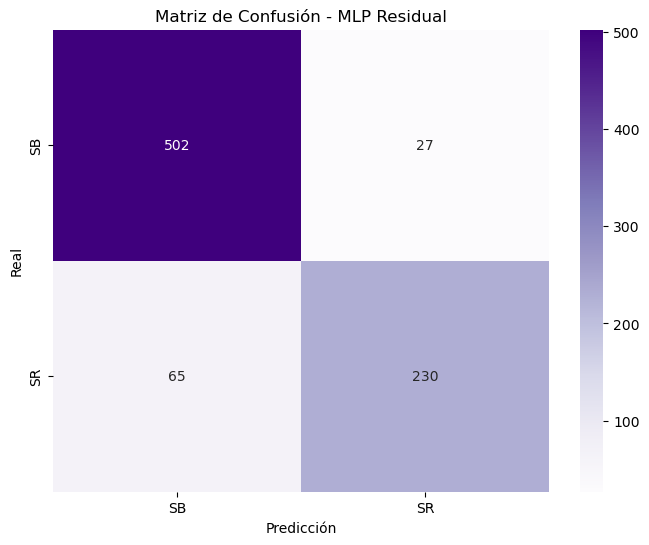


Reporte de clasificación - MLP Residual:

              precision    recall  f1-score   support

          SB       0.89      0.95      0.92       529
          SR       0.89      0.78      0.83       295

    accuracy                           0.89       824
   macro avg       0.89      0.86      0.87       824
weighted avg       0.89      0.89      0.89       824



In [20]:

# 1. Definición del modelo residual


# Capa de entrada
input_layer = Input(shape=(X_train.shape[1],))

# Primer bloque
x = Dense(64, activation='relu')(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Segundo bloque (residual)
res = Dense(64, activation='relu')(x)
res = BatchNormalization()(res)
res = Dropout(0.3)(res)

# Suma residual
x = Add()([x, res])

# Tercer bloque
x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)

# Capa de salida
output_layer = Dense(len(np.unique(y_encoded)), activation='softmax')(x)

# Modelo final
residual_model = Model(inputs=input_layer, outputs=output_layer)

residual_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])


# 2. Entrenamiento

history_res = residual_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)

# 3. Evaluación

train_loss_r, train_acc_r = residual_model.evaluate(X_train, y_train, verbose=0)
test_loss_r, test_acc_r = residual_model.evaluate(X_test, y_test, verbose=0)

print(f"\n MLP con conexión residual:")
print(f"Precisión en entrenamiento: {train_acc_r:.4f}")
print(f"Precisión en prueba: {test_acc_r:.4f}")


# 4. Matriz de confusión

y_pred_r = residual_model.predict(X_test)
y_pred_classes_r = np.argmax(y_pred_r, axis=1)

cm_r = confusion_matrix(y_test, y_pred_classes_r)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_r, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Purples')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - MLP Residual')
plt.show()

# 5. Reporte de clasificación

print("\nReporte de clasificación - MLP Residual:\n")
print(classification_report(y_test, y_pred_classes_r, target_names=class_names))


 Red con atención simple:
Precisión en entrenamiento: 0.9034
Precisión en prueba: 0.8774
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


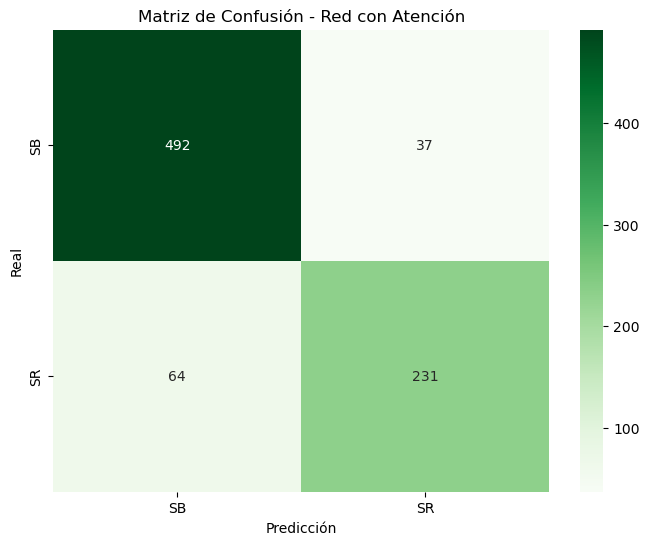


Reporte de clasificación - Red con Atención:

              precision    recall  f1-score   support

          SB       0.88      0.93      0.91       529
          SR       0.86      0.78      0.82       295

    accuracy                           0.88       824
   macro avg       0.87      0.86      0.86       824
weighted avg       0.88      0.88      0.88       824



In [21]:

# 1. Red con atención sobre features

# Capa de entrada
input_layer = Input(shape=(X_train.shape[1],))

# Generamos un vector de pesos de atención
attention_probs = Dense(X_train.shape[1], activation='softmax', name='attention_vec')(input_layer)

# Aplicamos la atención: se ponderan las entradas
attention_mul = Multiply()([input_layer, attention_probs])

# Capa oculta tradicional después de atención
x = Dense(64, activation='relu')(attention_mul)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)

# Capa de salida
output_layer = Dense(len(np.unique(y_encoded)), activation='softmax')(x)

# Definir modelo
attention_model = Model(inputs=input_layer, outputs=output_layer)

attention_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])


# 2. Entrenamiento

history_att = attention_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)


# 3. Evaluación

train_loss_a, train_acc_a = attention_model.evaluate(X_train, y_train, verbose=0)
test_loss_a, test_acc_a = attention_model.evaluate(X_test, y_test, verbose=0)

print(f"\n Red con atención simple:")
print(f"Precisión en entrenamiento: {train_acc_a:.4f}")
print(f"Precisión en prueba: {test_acc_a:.4f}")

# 4. Matriz de confusión

y_pred_a = attention_model.predict(X_test)
y_pred_classes_a = np.argmax(y_pred_a, axis=1)

cm_a = confusion_matrix(y_test, y_pred_classes_a)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_a, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Red con Atención')
plt.show()


# 5. Reporte de clasificación

print("\nReporte de clasificación - Red con Atención:\n")
print(classification_report(y_test, y_pred_classes_a, target_names=class_names))

XGBoost

In [22]:
# Separar características y etiquetas
X = df_procesar.drop('Rhythm', axis=1)
y = df_procesar['Rhythm']

# División 80% entrenamiento, 20% prueba (con estratificación para mantener proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (4476, 8)
Tamaño prueba: (1120, 8)


In [23]:
!pip install xgboost

In [24]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Variables predictoras y objetivo
X = df_procesar.drop(columns=['Rhythm'])  # Asumiendo que esta es tu variable objetivo
y = df_procesar['Rhythm']

# Codificar las clases (AFIB, SB, SR, SVT) a enteros
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Entrenar el modelo
model_xgb = xgb.XGBClassifier( eval_metric='mlogloss', random_state=42)
model_xgb.fit(X_train, y_train)

# Predicciones
y_pred = model_xgb.predict(X_test)

# Precisión
train_acc = accuracy_score(y_train, model_xgb.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)

Resultado XGBoost:
Precisión en prueba: 0.8705
Precisión en entrenamiento: 1.0000


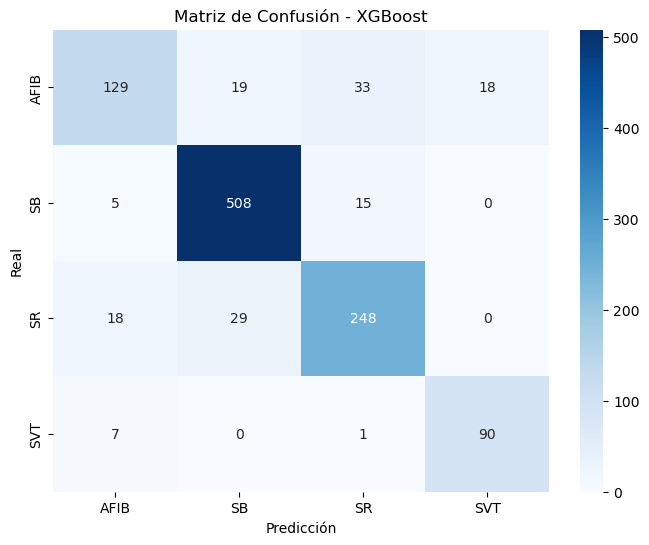

Reporte de clasificación - XGBoost:
              precision    recall  f1-score   support

        AFIB       0.81      0.65      0.72       199
          SB       0.91      0.96      0.94       528
          SR       0.84      0.84      0.84       295
         SVT       0.83      0.92      0.87        98

    accuracy                           0.87      1120
   macro avg       0.85      0.84      0.84      1120
weighted avg       0.87      0.87      0.87      1120



In [25]:
# Matriz de confusión
# Reporte
print("Resultado XGBoost:")
print(f"Precisión en prueba: {test_acc:.4f}")
print(f"Precisión en entrenamiento: {train_acc:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - XGBoost')
plt.show()

print("Reporte de clasificación - XGBoost:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

| Modelo           | Precisión Prueba | Macro F1 | Weighted F1 |
| ---------------- | ---------------- | -------- | ----------- |
| MLP Base         | 0.8277           | 0.81     | 0.82        |
| MLP Profundo     | 0.8241           | 0.78     | 0.82        |
| MLP Residual     | 0.8384           | 0.81     | 0.83        |
| Red con Atención | 0.8241           | 0.80     | 0.82        |
| **XGBoost**      | **0.8705**       | **0.84** | **0.87**    |


7) Realizar y discutir un ejemplo con los datos, del algoritmo de K means  y máquinas de soporte vectorial (SVM) 

Índice Rand Ajustado (ARI) para K-Means: 0.2430


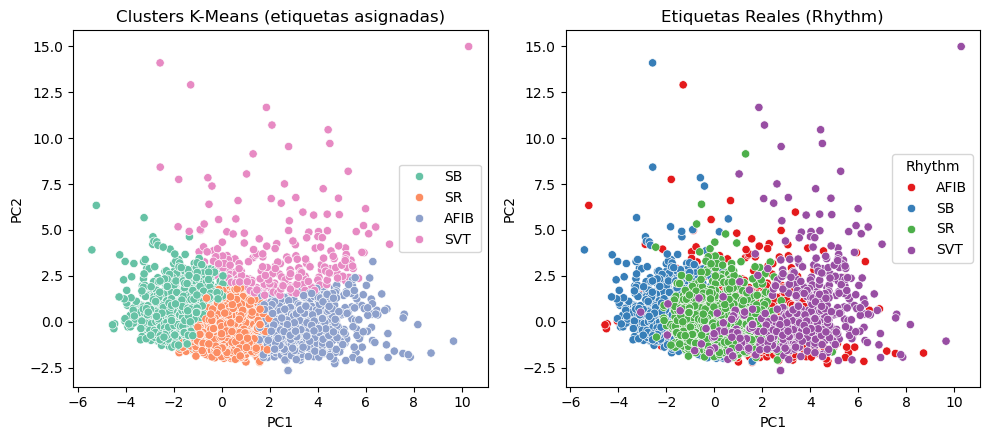


Reporte de clasificación - SVM:

              precision    recall  f1-score   support

        AFIB       0.80      0.50      0.62       199
          SB       0.84      0.95      0.89       528
          SR       0.75      0.71      0.73       295
         SVT       0.80      0.96      0.87        98

    accuracy                           0.81      1120
   macro avg       0.80      0.78      0.78      1120
weighted avg       0.81      0.81      0.80      1120



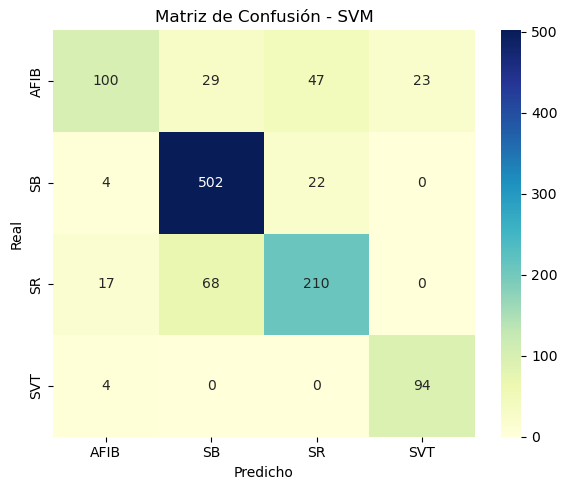

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Separar características y etiquetas
X = df_procesar.drop('Rhythm', axis=1)
y = df_procesar['Rhythm']

# Codificación de etiquetas
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === K-MEANS ===
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# ARI (Índice de Rand Ajustado)
ari_score = adjusted_rand_score(y_encoded, clusters)
print(f"Índice Rand Ajustado (ARI) para K-Means: {ari_score:.4f}")

# === Mapear cada cluster al nombre real más común ===
df_kmeans = pd.DataFrame({'cluster': clusters, 'real_label': y})
cluster_to_label = (
    df_kmeans.groupby('cluster')['real_label']
    .agg(lambda x: x.mode()[0])  # etiqueta más común por cluster
    .to_dict()
)

# Crear nueva columna con nombre de clase asignado al cluster
cluster_named = [cluster_to_label[c] for c in clusters]

# === PCA para visualización ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 4.5))

# Gráfico 1: Clustering con nombres reales
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_named, palette='Set2')
plt.title("Clusters K-Means (etiquetas asignadas)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# Gráfico 2: Etiquetas reales
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1')
plt.title("Etiquetas Reales (Rhythm)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.savefig("kmeans_vs_real_named.png", dpi=300)
plt.show()

# === SVM ===
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded,test_size=0.2,stratify=y_encoded,random_state=42)

svm_model = SVC(kernel='rbf', C=1.0)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

# Reporte de desempeño
print("\nReporte de clasificación - SVM:\n")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - SVM")
plt.tight_layout()
plt.savefig("svm_confusion_matrix.png", dpi=300)
plt.show()
